# Bank Marketing — Out-of-Domain Generalisation Study

This notebook replicates the synthetic data evaluation pipeline established on the
UCI Default of Credit Card Clients dataset, applied to a second, out-of-domain
dataset: the UCI Bank Marketing dataset (Moro et al., 2014). The goal is to test
whether the conclusions drawn on the first dataset generalise to a structurally
different financial dataset.

**Dataset:** Direct marketing campaigns of a Portuguese bank. Target `y`: whether
the client subscribed a term deposit. 41,188 records, ~11.27% minority (more
imbalanced than the ~22% of the Default dataset).

In [ ]:
# Folders used by this notebook, relative to it: CSV inputs/outputs in data/,
# figures in figures/, trained CTAB-GAN+ models in models/.
from pathlib import Path
for folder in ("data", "figures", "models"):
    Path(folder).mkdir(exist_ok=True)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             f1_score, recall_score, precision_score)
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: fixed across the entire pipeline (mirrors Dataset 1)
RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)

## 1. Data Loading and Formatting

The dataset uses `;` as separator. We load `bank-additional-full.csv` (the richer,
canonical version with 20 inputs and socio-economic indicators, as used in
Moro et al., 2014).

In [2]:
# Note: bank-additional-full.csv uses ';' as the field separator
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

print(f"Shape: {df.shape}")           # (41188, 21)
print(f"Missing values: {df.isnull().sum().sum()}")   # 0
df.head()

Shape: (41188, 21)
Missing values: 0


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Data Integrity

We verify structural integrity before any transformation: missing values,
duplicate records, and data types. Duplicates are measured on the **original**
data (before feature removal): removing `duration` later would make many distinct
calls appear identical, so the true duplicate count must be taken here.

In [3]:
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows (original data): {df.duplicated().sum()}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

# 12 exact-duplicate rows (0.03%). With no unique client identifier, these may be
# distinct clients sharing an identical profile; given the negligible fraction,
# they are retained (consistent with common practice on this dataset).

Shape: (41188, 21)
Missing values: 0
Duplicate rows (original data): 12

Data types:
object     11
int64       5
float64     5
Name: count, dtype: int64


## 3. Data Cleaning

Four decisions, guided by the Bank Marketing literature (Moro et al., 2014):
- **`duration` removed:** known target leakage (only known after the call ends;
  duration=0 implies y=no). Discarded for a realistic predictive model.
- **`pdays` → binary `was_contacted`:** 96.3% of records hold the sentinel 999
  ("never previously contacted"). The numeric value is noise for almost all rows,
  so it is converted to a binary contacted/not-contacted flag.
- **`unknown` kept as a category:** in this dataset `unknown` is an explicit,
  potentially informative level (missingness itself can be predictive), not an
  undocumented error.
- **`default`:** only 3 records are "yes" (0.007%), too rare to synthesise
  reliably, so they are merged into `unknown`, leaving a no/unknown variable.

In [4]:
# 1. Remove duration (target leakage)
df = df.drop(columns=['duration'])

# 2. pdays -> binary flag (999 = never contacted, 96.3% of rows)
df['was_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])

# 3. Target to binary (1 = subscribed term deposit)
df['y'] = (df['y'] == 'yes').astype(int)

# 4. default: merge the 3 rare 'yes' into 'unknown'
df['default'] = df['default'].replace({'yes': 'unknown'})

print(f"Shape after cleaning: {df.shape}")
print(f"Minority (y=1): {df['y'].mean()*100:.2f}%")

Shape after cleaning: (41188, 20)
Minority (y=1): 11.27%


## 4. Feature Types

Column-type groups are defined once and reused across the entire pipeline. Adapted
to Bank Marketing: all categoricals are nominal (no ordinal columns, unlike the
PAY_X variables of Dataset 1). `was_contacted` is treated as categorical.

In [5]:
CATEGORICAL_COLS = ['job','marital','education','default','housing','loan',
                    'contact','month','day_of_week','poutcome','was_contacted']
CONTINUOUS_COLS  = ['age','campaign','previous','emp.var.rate','cons.price.idx',
                    'cons.conf.idx','euribor3m','nr.employed']
INTEGER_COLS     = ['age','campaign','previous']   # integer-valued continuous

# Sanity check: every non-target column is accounted for
assert set(CATEGORICAL_COLS + CONTINUOUS_COLS) == set(df.columns) - {'y'}
print(f"{len(CATEGORICAL_COLS)} categorical, {len(CONTINUOUS_COLS)} continuous, + target.")

11 categorical, 8 continuous, + target.


## 5. Exploratory Data Analysis

### 5.1 Class Imbalance
The target `y` (term deposit subscription) is imbalanced: 4,640 subscribers
(11.27%) against 36,548 non-subscribers, more severe than the ~22% minority of the
Default dataset and a stronger stress-test for the augmentation strategies.

No (0):  36,548 (88.73%)
Yes (1): 4,640 (11.27%)


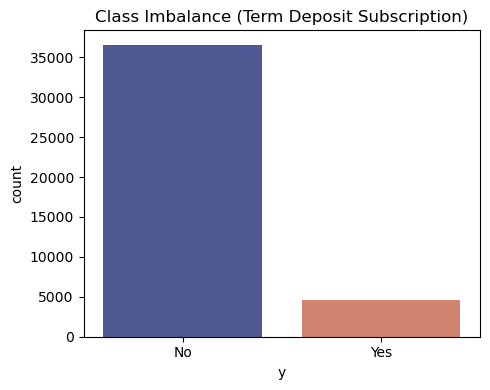

In [6]:
counts = df['y'].value_counts()
print(f"No (0):  {counts[0]:,} ({counts[0]/len(df)*100:.2f}%)")
print(f"Yes (1): {counts[1]:,} ({counts[1]/len(df)*100:.2f}%)")

plt.figure(figsize=(5,4))
sns.countplot(x='y', data=df, hue='y', palette=['#4251A0','#E07A5F'], legend=False)
plt.title('Class Imbalance (Term Deposit Subscription)')
plt.xticks([0,1], ['No', 'Yes'])
plt.tight_layout(); plt.show()

### 5.2 Demographic Profile
The client base has a mean age of 40 (median 38, range 17–98). Administrative and
blue-collar roles dominate; most clients are married with a university degree or
high-school education. Subscription rates vary sharply by segment: students (31.4%)
and retirees (25.2%) subscribe far above average, consistent with their greater
propensity to hold term deposits.

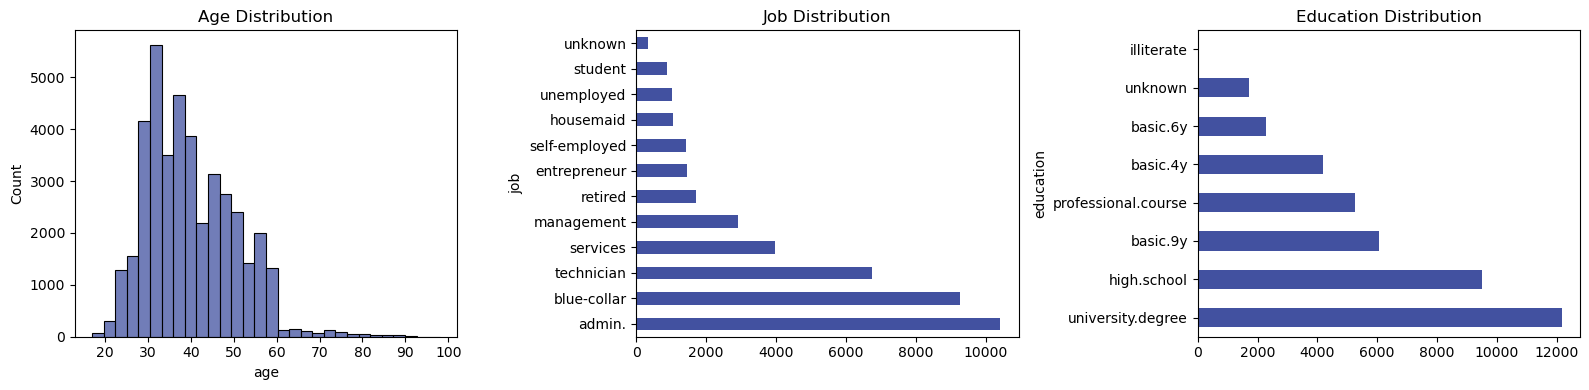

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(df['age'], bins=30, ax=axes[0], color='#4251A0')
axes[0].set_title('Age Distribution')
df['job'].value_counts().plot(kind='barh', ax=axes[1], color='#4251A0')
axes[1].set_title('Job Distribution')
df['education'].value_counts().plot(kind='barh', ax=axes[2], color='#4251A0')
axes[2].set_title('Education Distribution')
plt.tight_layout(); plt.show()

### 5.3 Predictive Signals
Subscription rate varies sharply across features, confirming their predictive value:
- **`poutcome`:** clients whose previous campaign succeeded subscribe at 65.11%,
  versus 8.83% for those never previously targeted.
- **`contact`:** cellular contact yields 14.74% versus 5.23% for telephone.
- **`month`:** March (50.55%), December (48.90%) and September (44.91%) far exceed
  May (6.43%), reflecting seasonal campaign effects.

In [8]:
for c in ['poutcome', 'contact', 'month']:
    rate = (df.groupby(c)['y'].mean()*100).round(2).sort_values(ascending=False)
    print(f"\nSubscription rate by {c}:\n{rate}")


Subscription rate by poutcome:
poutcome
success        65.11
failure        14.23
nonexistent     8.83
Name: y, dtype: float64

Subscription rate by contact:
contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64

Subscription rate by month:
month
mar    50.55
dec    48.90
sep    44.91
oct    43.87
apr    20.48
aug    10.60
jun    10.51
nov    10.14
jul     9.05
may     6.43
Name: y, dtype: float64


### 5.4 Socio-economic Interdependencies
The five socio-economic indicators are strongly intercorrelated: `euribor3m`,
`emp.var.rate` and `nr.employed` move together (r = 0.91–0.97). This mirrors the
sequential `BILL_AMT` correlations of the Default dataset and provides the natural
target for the Feature Interdependency audit (Property 7): a faithful generator
must reproduce this macro-economic correlation structure.

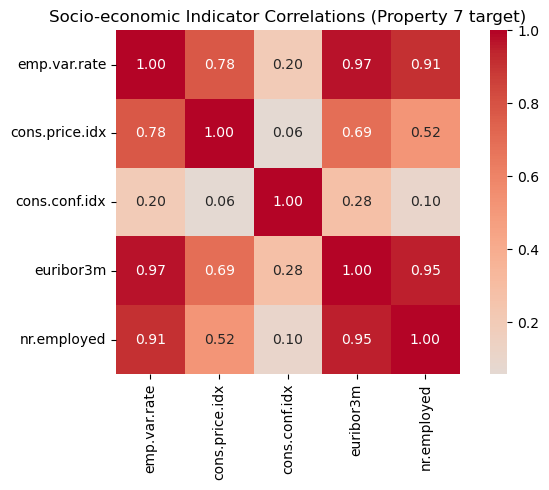

In [9]:
socio = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
plt.figure(figsize=(7,5))
sns.heatmap(df[socio].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Socio-economic Indicator Correlations (Property 7 target)')
plt.tight_layout(); plt.show()

REAL_SOCIO_CORR = df[socio].corr()   # store for synthetic comparison later

### 5.5 Extreme-Value Audit
Extreme values are inspected and confirmed as legitimate domain values (not errors),
so they are retained (mirrors the PAY_AMT audit of Dataset 1).

In [10]:
print(f"age > 90:      {(df['age']>90).sum()} clients (legitimate elderly clients)")
print(f"campaign > 30: {(df['campaign']>30).sum()} clients (persistent contact, plausible)")
print(f"age range:      [{df['age'].min()}, {df['age'].max()}]")
print(f"campaign range: [{df['campaign'].min()}, {df['campaign'].max()}]")

age > 90:      10 clients (legitimate elderly clients)
campaign > 30: 33 clients (persistent contact, plausible)
age range:      [17, 98]
campaign range: [1, 56]


### 5.6 PCA Manifold Visualisation (EDA only)
A 2D PCA projection visualises global structure and class separability. This is for
exploratory visualisation only: the scaler here is not the canonical one and no
information feeds the split or the models (no leakage). The projection and its
objects are stored so that, in the evaluation chapter, synthetic samples can be
projected onto the same space to assess whether the generators preserve the real
data manifold.

Explained variance: PC1 = 10.1%, PC2 = 5.0%, total = 15.2%


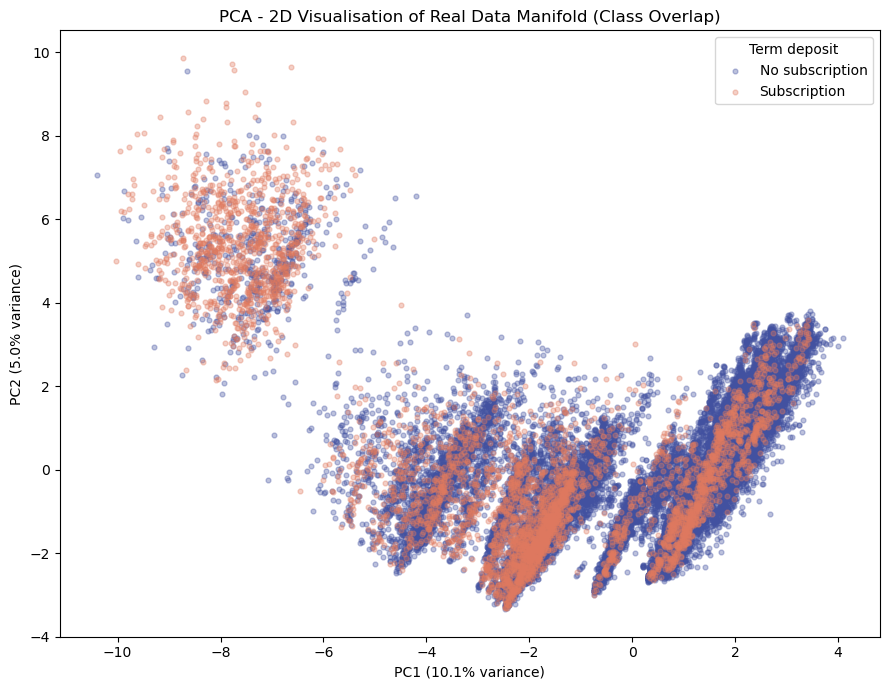


Insight: substantial class overlap in 2D indicates the decision boundary is not linearly separable, justifying non-linear generative models. Only 15.2% of variance is captured in 2D, reflecting the high-dimensional, mixed-type feature space.


In [11]:
# PCA: manifold visualisation (EDA ONLY - NO DATA LEAKAGE)
X_full_enc = pd.get_dummies(df.drop(columns=['y']), columns=CATEGORICAL_COLS).astype(float)
y_full = df['y']

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_full_enc)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['y'] = y_full.values

explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1 = {explained[0]:.1%}, PC2 = {explained[1]:.1%}, "
      f"total = {sum(explained):.1%}")

fig, ax = plt.subplots(figsize=(9,7))
for cls, label, color in zip([0,1], ['No subscription','Subscription'], ['#4251A0','#E07A5F']):
    mask = pca_df['y'] == cls
    ax.scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
               c=color, label=label, alpha=0.35, s=12)
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
ax.set_title("PCA - 2D Visualisation of Real Data Manifold (Class Overlap)")
ax.legend(title='Term deposit')
plt.tight_layout(); plt.show()

# Store for synthetic reprojection in the evaluation chapter (mirrors Dataset 1)
REAL_PCA_COMPONENTS = pca_df.copy()
PCA_OBJECTS = {'pca': pca, 'scaler_pca': scaler_pca,
               'feature_columns': list(X_full_enc.columns)}

print("\nInsight: substantial class overlap in 2D indicates the decision boundary "
      "is not linearly separable, justifying non-linear generative models. Only "
      "15.2% of variance is captured in 2D, reflecting the high-dimensional, "
      "mixed-type feature space.")

## 6. Canonical Train/Test Split (Pipeline Foundation)

This defines the single canonical split and preprocessing objects reused across
the entire pipeline (baselines, SMOTE, CTGAN, CTAB-GAN+), mirroring Dataset 1.
These objects must not be modified after this point.

- The split is performed **before** any scaling or encoding (no leakage).
- The `StandardScaler` is fitted **only** on the training continuous features.
- The `OneHotEncoder` is fitted **only** on the training categoricals
  (`handle_unknown='ignore'`), for the baseline and SMOTE.
- The GANs (CTGAN, CTAB-GAN+) receive **raw** data and encode internally.
- Stratified splitting preserves the ~11.27% minority rate in both sets.

In [12]:
# ===== CANONICAL SPLIT (foundation - do not modify downstream) =====
X = df.drop(columns=['y'])
y = df['y']

# Stratified 70/30 split BEFORE any scaling/encoding (prevents leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Transformers fitted on TRAIN only (scaler for continuous, OHE for categoricals)
scaler = StandardScaler().fit(X_train[CONTINUOUS_COLS])
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(X_train[CATEGORICAL_COLS])

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train minority: {y_train.mean()*100:.2f}%  Test minority: {y_test.mean()*100:.2f}%")
print(f"Scaler + OHE fitted on train only ({len(ohe.get_feature_names_out())} dummies). No leakage.")

X_train: (28831, 19), X_test: (12357, 19)
Train minority: 11.27%  Test minority: 11.26%
Scaler + OHE fitted on train only (54 dummies). No leakage.


In [13]:
# Real training subsets (foundation for all comparisons)
train_data_raw = X_train.copy()
train_data_raw['y'] = y_train.values
train_data_full    = train_data_raw.copy()                              # for CTAB-GAN+
train_minority_raw = train_data_raw[train_data_raw['y']==1].drop('y', axis=1).copy()
train_majority_raw = train_data_raw[train_data_raw['y']==0].drop('y', axis=1).copy()

print(f"train_data_full:    {train_data_full.shape}")
print(f"train_minority_raw: {train_minority_raw.shape}  (y==1)")
print(f"train_majority_raw: {train_majority_raw.shape}  (y==0)")

train_data_full:    (28831, 20)
train_minority_raw: (3248, 19)  (y==1)
train_majority_raw: (25583, 19)  (y==0)


## 7. Groundwork: Real-Data Reference Metrics

Before generating any synthetic data, we establish reference metrics on the real
data, mirroring the groundwork of Dataset 1. Each metric is anchored to a property
of the He et al. (2025) framework and serves as the ground truth against which the
synthetic generators are later evaluated. The real minority class (y=1) is the
target distribution the generators must approximate.

### 7.1 Reference Distributions (TVD, correlation, KDE)

In [14]:
def compute_tvd(series_a, series_b):
    """Total Variation Distance between two categorical distributions."""
    pa = series_a.value_counts(normalize=True)
    pb = series_b.value_counts(normalize=True)
    cats = set(pa.index) | set(pb.index)
    return 0.5 * sum(abs(pa.get(c, 0.0) - pb.get(c, 0.0)) for c in cats)

# 7.1 - TVD: real minority vs real majority (natural class-separation baseline).
# The intrinsic difficulty of the problem: a generator cannot be expected to
# produce TVD lower than the natural variation between the real classes.
REAL_TVD_REFERENCE = {c: round(compute_tvd(train_minority_raw[c],
                                           train_majority_raw[c]), 4)
                      for c in CATEGORICAL_COLS}
tvd_ref_df = (pd.DataFrame.from_dict(REAL_TVD_REFERENCE, orient='index',
                                     columns=['TVD (Min vs Maj)'])
              .sort_values('TVD (Min vs Maj)', ascending=False))
print(tvd_ref_df)

               TVD (Min vs Maj)
month                    0.2308
contact                  0.2221
poutcome                 0.2074
was_contacted            0.1901
job                      0.1512
default                  0.1239
education                0.0969
marital                  0.0769
day_of_week              0.0277
housing                  0.0258
loan                     0.0030


In [15]:
# 7.1 - Correlation matrix of the real minority (continuous features).
# Reference for the Feature Interdependency audit (Property 7).
REAL_MINORITY_CORR = train_minority_raw[CONTINUOUS_COLS].corr()
print(REAL_MINORITY_CORR.round(2))

                 age  campaign  previous  emp.var.rate  cons.price.idx  \
age             1.00      0.00      0.08         -0.08           -0.02   
campaign        0.00      1.00     -0.11          0.23            0.12   
previous        0.08     -0.11      1.00         -0.29            0.09   
emp.var.rate   -0.08      0.23     -0.29          1.00            0.65   
cons.price.idx -0.02      0.12      0.09          0.65            1.00   
cons.conf.idx   0.13     -0.05      0.12         -0.26           -0.33   
euribor3m      -0.09      0.22     -0.39          0.93            0.41   
nr.employed    -0.11      0.21     -0.49          0.79            0.11   

                cons.conf.idx  euribor3m  nr.employed  
age                      0.13      -0.09        -0.11  
campaign                -0.05       0.22         0.21  
previous                 0.12      -0.39        -0.49  
emp.var.rate            -0.26       0.93         0.79  
cons.price.idx          -0.33       0.41         0.11

In [16]:
# Continuous distribution statistics (minority baseline)
REAL_CONTINUOUS_STATS = train_minority_raw[CONTINUOUS_COLS].describe().T[['mean','std','min','max']]
print(REAL_CONTINUOUS_STATS.round(2))

                   mean    std      min      max
age               40.97  13.77    17.00    98.00
campaign           2.07   1.69     1.00    17.00
previous           0.49   0.86     0.00     6.00
emp.var.rate      -1.22   1.63    -3.40     1.40
cons.price.idx    93.36   0.67    92.20    94.77
cons.conf.idx    -39.86   6.16   -50.80   -26.90
euribor3m          2.13   1.75     0.63     5.04
nr.employed     5095.46  88.09  4963.60  5228.10


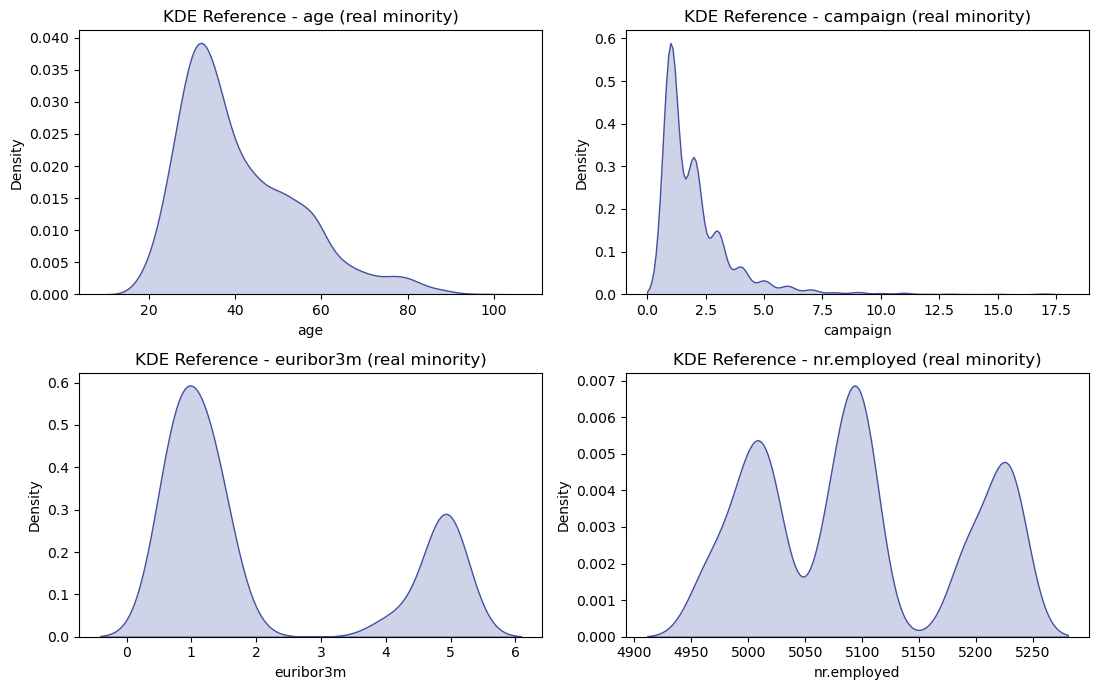

In [17]:
# 7.1 - KDE reference plots for key continuous variables (real minority)
key_cont = ['age','campaign','euribor3m','nr.employed']
fig, axes = plt.subplots(2, 2, figsize=(11,7))
for ax, col in zip(axes.ravel(), key_cont):
    sns.kdeplot(train_minority_raw[col], ax=ax, fill=True, color='#4251A0')
    ax.set_title(f'KDE Reference - {col} (real minority)')
plt.tight_layout(); plt.show()

### 7.2 Subscription Rates by Segment
Segment-level subscription rates are stored as reference artifacts (mirrors the
default-rate references of Dataset 1).

In [18]:
REAL_SUBSCRIPTION_RATES = {}
for feat in ['job','marital','education','poutcome','contact','month']:
    t = (df.groupby(feat)['y'].agg(['mean','count'])
         .rename(columns={'mean':'subscription_rate'}))
    t['subscription_rate'] *= 100
    REAL_SUBSCRIPTION_RATES[feat] = t.sort_values('subscription_rate', ascending=False)

print("Subscription rates computed for:", list(REAL_SUBSCRIPTION_RATES.keys()))
REAL_SUBSCRIPTION_RATES['job'].round(2)

Subscription rates computed for: ['job', 'marital', 'education', 'poutcome', 'contact', 'month']


,subscription_rate,count
job,,
student,31.43,875
retired,25.23,1720
unemployed,14.20,1014
admin.,12.97,10422
management,11.22,2924
unknown,11.21,330
technician,10.83,6743
self-employed,10.49,1421
housemaid,10.00,1060


### 7.3 Formal Domain Rules (He et al. Property 6 — Feasibility)
Feasibility rules are redefined for the Bank Marketing feature space. Rules are
derived from the exact values of the full real dataset (not rounded) so that real
data itself never registers as a violation. Demographic attributes are immutable
(Property 5).

In [19]:
# 7.3 - Formal domain rules (He et al., 2025): P6 (Feasibility), P5 (Immutability)
DOMAIN_RULES = {c: {'min': df[c].min(), 'max': df[c].max(),
                    'type': 'int' if c in INTEGER_COLS else 'float'}
                for c in CONTINUOUS_COLS}

VALID_CATEGORIES = {c: sorted(df[c].unique().tolist()) for c in CATEGORICAL_COLS}

IMMUTABLE_FEATURES = ['marital', 'education', 'job']   # Property 5

print(f"{len(DOMAIN_RULES)} continuous ranges, {len(VALID_CATEGORIES)} categorical "
      f"rule sets, {len(IMMUTABLE_FEATURES)} immutable features")

8 continuous ranges, 11 categorical rule sets, 3 immutable features


In [20]:
def audit_domain_violations(synthetic_df, label="Synthetic"):
    """Audit synthetic data against domain rules (He et al. Property 6)."""
    report = {}
    for col, r in DOMAIN_RULES.items():
        if col in synthetic_df.columns:
            v = ((synthetic_df[col] < r['min']) | (synthetic_df[col] > r['max'])).sum()
            report[col] = {'violations': int(v), 'pct': round(v/len(synthetic_df)*100, 2)}
    for col, valid in VALID_CATEGORIES.items():
        if col in synthetic_df.columns:
            v = (~synthetic_df[col].isin(valid)).sum()
            report[col] = {'violations': int(v), 'pct': round(v/len(synthetic_df)*100, 2)}
    return report

# Sanity check: real data must have ZERO violations
_check = audit_domain_violations(train_minority_raw, "Real Minority")
assert sum(r['violations'] for r in _check.values()) == 0, "Real data violates rules!"
print("Domain audit function verified: real minority has 0 violations.")

Domain audit function verified: real minority has 0 violations.


### 7.4 Core Statistical Fidelity Function
`compute_fidelity_report` computes the full fidelity profile of a synthetic dataset
against the real minority: TVD (categoricals), KS and Wasserstein (continuous), the
Frobenius norm between correlation matrices (Property 7), nearest-neighbour
proximity (Property 1), the OOD rate (Property 2), and the z-score sensitivity rate
(Property 4). Mirrors Dataset 1, adapted (no ordinal columns; nominal categoricals).

In [21]:
def compute_ks(series_a, series_b):
    r = stats.ks_2samp(series_a, series_b)
    return r.statistic, r.pvalue

def compute_wasserstein(series_a, series_b):
    return stats.wasserstein_distance(series_a, series_b)


def compute_fidelity_report(real_df, synthetic_df, label="Synthetic"):
    """Complete statistical fidelity report (mirrors Dataset 1, adapted)."""
    rows = []
    # TVD - categorical (nominal; no rounding, values are strings/flags)
    for col in CATEGORICAL_COLS:
        tvd = compute_tvd(real_df[col], synthetic_df[col])
        rows.append({"Column": col, "Type": "categorical", "Metric": "TVD",
                     "Value": round(tvd, 4), "Lower_is_better": True})
    # KS + Wasserstein - continuous
    for col in CONTINUOUS_COLS:
        ks_stat, ks_pval = compute_ks(real_df[col].astype(float), synthetic_df[col].astype(float))
        wass = compute_wasserstein(real_df[col].astype(float), synthetic_df[col].astype(float))
        rows.append({"Column": col, "Type": "continuous", "Metric": "KS",
                     "Value": round(ks_stat, 4), "p_value": round(ks_pval, 4), "Lower_is_better": True})
        rows.append({"Column": col, "Type": "continuous", "Metric": "Wasserstein",
                     "Value": round(wass, 2), "Lower_is_better": True})
    result_df = pd.DataFrame(rows)

    # Frobenius norm between correlation matrices (Property 7)
    real_corr  = real_df[CONTINUOUS_COLS].astype(float).corr().values
    synth_corr = synthetic_df[CONTINUOUS_COLS].astype(float).corr().values
    frob_norm  = np.linalg.norm(real_corr - synth_corr, "fro")

    # Proximity: mean nearest-neighbour distance (Property 1)
    real_scaled  = StandardScaler().fit_transform(real_df[CONTINUOUS_COLS].astype(float))
    synth_scaled = StandardScaler().fit_transform(synthetic_df[CONTINUOUS_COLS].astype(float))
    nbrs = NearestNeighbors(n_neighbors=1).fit(real_scaled)
    distances, _ = nbrs.kneighbors(synth_scaled)
    mean_proximity = distances.mean()

    # OOD rate (Sparsity proxy - Property 2): % outside real P5-P95
    ood_count = 0
    for col in CONTINUOUS_COLS:
        p05, p95 = real_df[col].quantile(0.05), real_df[col].quantile(0.95)
        ood_count += ((synthetic_df[col] < p05) | (synthetic_df[col] > p95)).sum()
    ood_rate = ood_count / (len(synthetic_df) * len(CONTINUOUS_COLS))

    # Z-score sensitivity (Property 4): % with >3 features at |z|>2
    mean_real = real_df[CONTINUOUS_COLS].astype(float).mean()
    std_real  = real_df[CONTINUOUS_COLS].astype(float).std()
    z_scores  = ((synthetic_df[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()
    high_sens_rate = ((z_scores > 2).sum(axis=1) > 3).mean()

    summary = {
        "label": label,
        "mean_TVD_cat":   result_df[(result_df["Type"]=="categorical") & (result_df["Metric"]=="TVD")]["Value"].mean(),
        "mean_KS_cont":   result_df[(result_df["Type"]=="continuous") & (result_df["Metric"]=="KS")]["Value"].mean(),
        "mean_Wass_cont": result_df[(result_df["Type"]=="continuous") & (result_df["Metric"]=="Wasserstein")]["Value"].mean(),
        "frobenius_delta": round(frob_norm, 4),
        "mean_proximity":  round(mean_proximity, 4),
        "ood_rate":        round(ood_rate, 4),
        "high_sensitivity_rate": round(high_sens_rate, 4),
    }
    print(f"\n=== Fidelity Report - {label} ===")
    for k, v in summary.items():
        if k != "label":
            print(f"  {k:24s}: {v}")
    return result_df, summary

# Sanity check: real vs itself must give ~0 on all metrics
_r, _s = compute_fidelity_report(train_minority_raw, train_minority_raw, "Real-vs-Real")
assert _s['mean_TVD_cat'] == 0 and _s['mean_KS_cont'] == 0, "fidelity function error!"
print("\ncompute_fidelity_report verified (real-vs-real = 0).")


=== Fidelity Report - Real-vs-Real ===
  mean_TVD_cat            : 0.0
  mean_KS_cont            : 0.0
  mean_Wass_cont          : 0.0
  frobenius_delta         : 0.0
  mean_proximity          : 0.0
  ood_rate                : 0.048
  high_sensitivity_rate   : 0.0

compute_fidelity_report verified (real-vs-real = 0).


### 7.5 Save Reference Artifacts
Real-data reference artifacts are saved to CSV (all prefixed `bank_` to distinguish
from Dataset 1). The evaluation chapter loads and compares against these.

In [22]:
# Base datasets
train_minority_raw.to_csv("data/bank_real_minority_train.csv", index=False)
train_data_full.to_csv("data/bank_real_train_full.csv", index=False)

# Reference metrics
REAL_CONTINUOUS_STATS.to_csv("data/bank_real_continuous_stats.csv")
REAL_MINORITY_CORR.to_csv("data/bank_real_minority_correlation.csv")
pd.DataFrame.from_dict(REAL_TVD_REFERENCE, orient="index",
                       columns=["TVD_minority_vs_majority"]).to_csv("data/bank_real_tvd_reference.csv")

# Subscription rates per segment (mirrors real_default_rate_*.csv of Dataset 1)
for feat, df_sr in REAL_SUBSCRIPTION_RATES.items():
    df_sr.to_csv(f"data/bank_real_subscription_rate_{feat}.csv")

print("Reference artifacts saved (all prefixed 'bank_'):")
print("  bank_real_minority_train.csv         - minority training set")
print("  bank_real_train_full.csv             - full training set (for CTAB-GAN+)")
print("  bank_real_continuous_stats.csv       - continuous reference statistics")
print("  bank_real_minority_correlation.csv   - correlation matrix (Property 7)")
print("  bank_real_tvd_reference.csv          - TVD minority vs majority")
print("  bank_real_subscription_rate_*.csv    - subscription rates by segment")

Reference artifacts saved (all prefixed 'bank_'):
  bank_real_minority_train.csv         - minority training set
  bank_real_train_full.csv             - full training set (for CTAB-GAN+)
  bank_real_continuous_stats.csv       - continuous reference statistics
  bank_real_minority_correlation.csv   - correlation matrix (Property 7)
  bank_real_tvd_reference.csv          - TVD minority vs majority
  bank_real_subscription_rate_*.csv    - subscription rates by segment


## 8. Baseline Models and SMOTE

Following Dataset 1, we establish performance baselines with Logistic Regression
and Random Forest on the real (imbalanced) data, then apply SMOTE as the geometric
oversampling baseline. All models are evaluated on the untouched real test set
(TSTR paradigm). Metrics emphasise minority-class recall and PR-AUC rather than
accuracy, which is misleading under imbalance.

In [23]:
# The classifiers and SMOTE require a numeric matrix. Unlike Dataset 1 (whose
# categoricals were already integer-coded), Bank Marketing categoricals are strings,
# so we combine one-hot encoding (categoricals) with scaling (continuous) using the
# transformers fitted on the training set. Returns a named DataFrame for clarity.
def build_matrix(X_df):
    cont = scaler.transform(X_df[CONTINUOUS_COLS])
    cat  = ohe.transform(X_df[CATEGORICAL_COLS])
    cat_names = list(ohe.get_feature_names_out(CATEGORICAL_COLS))
    return pd.DataFrame(np.hstack([cont, cat]),
                        columns=CONTINUOUS_COLS + cat_names, index=X_df.index)

X_train_enc = build_matrix(X_train)
X_test_enc  = build_matrix(X_test)
print(f"Encoded matrices: X_train_enc {X_train_enc.shape}, X_test_enc {X_test_enc.shape}")

Encoded matrices: X_train_enc (28831, 62), X_test_enc (12357, 62)


In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model(model, X_test_s, y_test, model_name, cmap="Blues"):
    """Evaluate a classifier on the real test set. Metrics tuned for imbalance:
    ROC-AUC, PR-AUC, and minority-class recall/precision/F1 (not accuracy)."""
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    report = classification_report(y_test, y_pred,
                                   target_names=["No", "Subscribe"], output_dict=True)
    auc      = roc_auc_score(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)

    print("=" * 60)
    print(f"{model_name} - CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=["No", "Subscribe"]))
    print(f"  ROC-AUC:            {auc:.4f}")
    print(f"  Avg Precision (PR): {avg_prec:.4f}")
    print(f"  Minority Recall:    {report['Subscribe']['recall']:.4f}")
    print(f"  Minority Precision: {report['Subscribe']['precision']:.4f}")
    print(f"  Minority F1:        {report['Subscribe']['f1-score']:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Subscribe"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f"{model_name}\nConfusion Matrix  |  FN={fn}  |  FP={fp}")
    plt.tight_layout(); plt.show()

    return {"model_name": model_name, "auc": auc, "avg_precision": avg_prec,
            "macro_f1": report["macro avg"]["f1-score"],
            "minority_recall": report["Subscribe"]["recall"],
            "minority_precision": report["Subscribe"]["precision"],
            "minority_f1": report["Subscribe"]["f1-score"],
            "accuracy": report["accuracy"], "y_prob": y_prob, "y_pred": y_pred}

### 8.1 Baseline (Real Data)
Logistic Regression and Random Forest trained on the real imbalanced training set.
These establish the reference against which augmentation is measured. Under
imbalance, both models achieve low minority recall, confirming the need for
augmentation. Logistic Regression and Random Forest are standard choices for
credit and marketing classification tasks.

Logistic Regression - Baseline - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.91      0.98      0.95     10965
   Subscribe       0.65      0.23      0.34      1392

    accuracy                           0.90     12357
   macro avg       0.78      0.61      0.64     12357
weighted avg       0.88      0.90      0.88     12357

  ROC-AUC:            0.7997
  Avg Precision (PR): 0.4577
  Minority Recall:    0.2263
  Minority Precision: 0.6535
  Minority F1:        0.3362


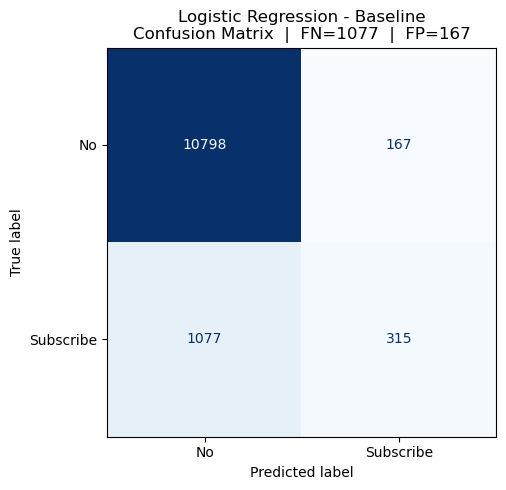

Random Forest - Baseline - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.91      0.97      0.94     10965
   Subscribe       0.53      0.28      0.37      1392

    accuracy                           0.89     12357
   macro avg       0.72      0.62      0.65     12357
weighted avg       0.87      0.89      0.88     12357

  ROC-AUC:            0.7721
  Avg Precision (PR): 0.4102
  Minority Recall:    0.2802
  Minority Precision: 0.5306
  Minority F1:        0.3667


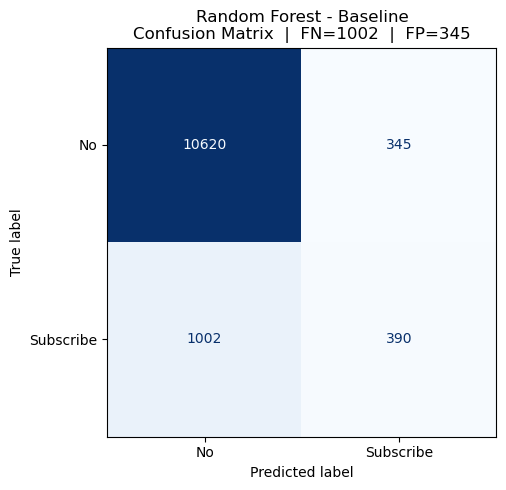

In [25]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
rf_clf  = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)

log_reg.fit(X_train_enc, y_train)
rf_clf.fit(X_train_enc, y_train)

results_lr_base = evaluate_model(log_reg, X_test_enc, y_test, "Logistic Regression - Baseline", "Blues")
results_rf_base = evaluate_model(rf_clf,  X_test_enc, y_test, "Random Forest - Baseline", "Blues")

### 8.2 SMOTE (Geometric Oversampling Baseline)
SMOTE (Chawla et al., 2002) is applied only to the training data; the test set
stays untouched (TSTR). Höllig et al. (2025) note that SMOTE achieves competitive
utility-privacy scores because its interpolation does not memorise individual
records, making it an important baseline.

--- Before SMOTE ---
y
0    25583
1     3248
Name: count, dtype: int64

--- After SMOTE ---
y
0    25583
1    25583
Name: count, dtype: int64
New training set shape: (51166, 62)
Logistic Regression - SMOTE - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.95      0.85      0.90     10965
   Subscribe       0.35      0.65      0.45      1392

    accuracy                           0.82     12357
   macro avg       0.65      0.75      0.67     12357
weighted avg       0.88      0.82      0.85     12357

  ROC-AUC:            0.7996
  Avg Precision (PR): 0.4542
  Minority Recall:    0.6451
  Minority Precision: 0.3486
  Minority F1:        0.4526


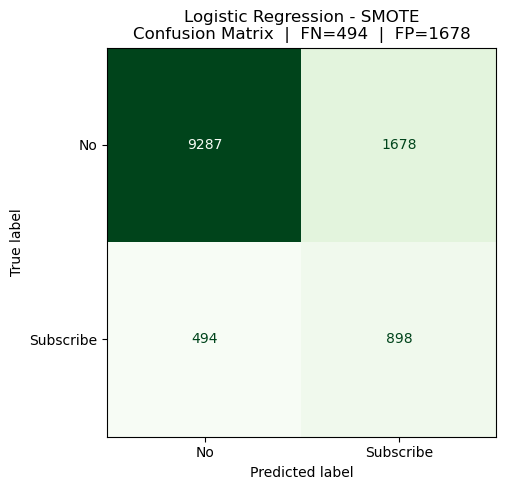

Random Forest - SMOTE - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.92      0.96      0.94     10965
   Subscribe       0.49      0.34      0.40      1392

    accuracy                           0.89     12357
   macro avg       0.70      0.65      0.67     12357
weighted avg       0.87      0.89      0.88     12357

  ROC-AUC:            0.7726
  Avg Precision (PR): 0.3998
  Minority Recall:    0.3362
  Minority Precision: 0.4906
  Minority F1:        0.3990


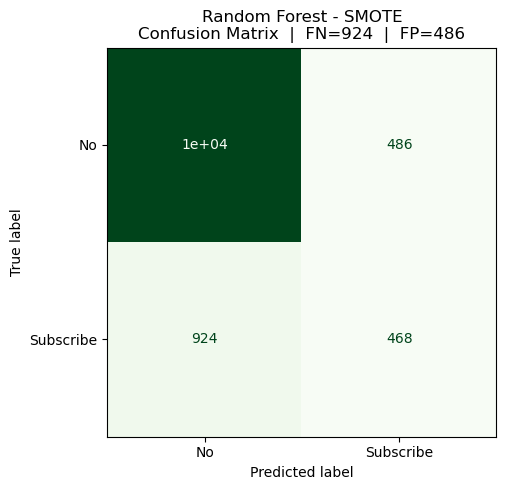

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

print("--- Before SMOTE ---"); print(y_train.value_counts())
print("\n--- After SMOTE ---");  print(pd.Series(y_train_smote).value_counts())
print(f"New training set shape: {X_train_smote.shape}")

log_reg_smote = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
rf_clf_smote  = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)

log_reg_smote.fit(X_train_smote, y_train_smote)
rf_clf_smote.fit(X_train_smote, y_train_smote)

results_lr_smote = evaluate_model(log_reg_smote, X_test_enc, y_test, "Logistic Regression - SMOTE", "Greens")
results_rf_smote = evaluate_model(rf_clf_smote,  X_test_enc, y_test, "Random Forest - SMOTE", "Greens")

### 8.3 CTGAN (Conditional Tabular GAN)

CTGAN (Xu et al., 2019) is trained only on the minority class from the raw
(unscaled) training data. Its Mode-Specific Normalisation handles the multimodal
continuous distributions observed in the EDA (the bimodal `euribor3m` and
trimodal `nr.employed`). Training on raw data is required: CTGAN encodes
categoricals internally, so pre-scaling would corrupt them.

In [27]:
try:
    from ctgan import CTGAN
    CTGAN_AVAILABLE = True
    print("CTGAN imported successfully.")
except ImportError as e:
    print(f"ERROR: Could not import CTGAN: {e}")
    CTGAN_AVAILABLE = False

if CTGAN_AVAILABLE:
    import time, torch
    torch.manual_seed(RANDOM_STATE)

    assert "train_minority_raw" in globals(), "run the groundwork first"

    # Discrete columns: all categoricals + the binary flag + target
    discrete_columns = CATEGORICAL_COLS + ['y']

    # CTGAN trains on the minority with the target column present
    train_minority_for_ctgan = train_minority_raw.copy()
    train_minority_for_ctgan['y'] = 1

    ctgan_model = CTGAN(epochs=300, batch_size=500, verbose=True)
    print("\nTraining CTGAN on the minority class (raw, unscaled)...")
    start = time.time()
    ctgan_model.fit(train_minority_for_ctgan, discrete_columns)
    print(f"CTGAN training completed in {(time.time()-start)/60:.2f} minutes.")

    # Generate enough to reach 50/50 balance
    samples_to_generate = (y_train == 0).sum() - (y_train == 1).sum()
    print(f"\nGenerating {samples_to_generate} synthetic minority instances...")
    synthetic_ctgan = ctgan_model.sample(samples_to_generate)
    print(f"Synthetic data shape: {synthetic_ctgan.shape}")
else:
    synthetic_ctgan = None

CTGAN imported successfully.

Training CTGAN on the minority class (raw, unscaled)...


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Gen. (-00.89) | Discrim. (-00.30): 100%|██████████| 300/300 [01:10<00:00,  4.28it/s]


CTGAN training completed in 1.43 minutes.

Generating 22335 synthetic minority instances...
Synthetic data shape: (22335, 20)


### 8.4 CTGAN Domain Validation and Correction
Before use, the synthetic data is audited against the domain rules (He et al.
Property 6). Any violations (continuous values outside valid ranges, invalid
categories) are quantified, then corrected. Quantifying violations before
correction provides the empirical evidence for the domain-compliance comparison
between generators.

In [28]:
if synthetic_ctgan is not None:
    # 1. AUDIT before correction (this is the evidence for the evaluation chapter)
    print("=== CTGAN domain violations BEFORE correction ===")
    violations_before = audit_domain_violations(synthetic_ctgan, "CTGAN")
    total_before = sum(r['violations'] for r in violations_before.values())
    for col, r in violations_before.items():
        if r['violations'] > 0:
            print(f"  {col:16}: {r['violations']:5} ({r['pct']}%)")
    print(f"  TOTAL violations: {total_before}")

    # 2. CORRECT
    def correct_domain_violations(synth_df):
        """Correct domain violations (He et al. P5/P6): clip continuous to valid
        ranges, round integer columns, map invalid categories to the real mode."""
        df_c = synth_df.copy()
        for col, r in DOMAIN_RULES.items():
            if col in df_c.columns:
                df_c[col] = df_c[col].clip(r['min'], r['max'])
                if r['type'] == 'int':
                    df_c[col] = df_c[col].round().astype(int)
        for col, valid in VALID_CATEGORIES.items():
            if col in df_c.columns:
                invalid = ~df_c[col].isin(valid)
                if invalid.any():
                    df_c.loc[invalid, col] = train_minority_raw[col].mode()[0]
        return df_c

    synthetic_ctgan_corrected = correct_domain_violations(synthetic_ctgan)

    # 3. VERIFY no violations remain
    after = audit_domain_violations(synthetic_ctgan_corrected, "CTGAN corrected")
    total_after = sum(r['violations'] for r in after.values())
    assert total_after == 0, f"still {total_after} violations!"
    print(f"\n=== AFTER correction: {total_after} violations. ===")

=== CTGAN domain violations BEFORE correction ===
  age             :   177 (0.79%)
  emp.var.rate    :  2463 (11.03%)
  cons.price.idx  :  1875 (8.39%)
  cons.conf.idx   :  1769 (7.92%)
  euribor3m       :  3685 (16.5%)
  nr.employed     :  3795 (16.99%)
  TOTAL violations: 13764

=== AFTER correction: 0 violations. ===


CTGAN-augmented training set: (51166, 62)
Balance: {0: 25583, 1: 25583}
Logistic Regression - CTGAN - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.94      0.83      0.88     10965
   Subscribe       0.32      0.61      0.42      1392

    accuracy                           0.81     12357
   macro avg       0.63      0.72      0.65     12357
weighted avg       0.87      0.81      0.83     12357

  ROC-AUC:            0.7648
  Avg Precision (PR): 0.3997
  Minority Recall:    0.6149
  Minority Precision: 0.3176
  Minority F1:        0.4189


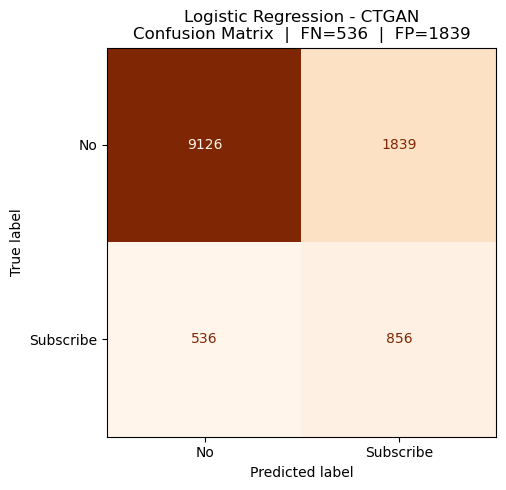

Random Forest - CTGAN - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.92      0.97      0.94     10965
   Subscribe       0.53      0.31      0.39      1392

    accuracy                           0.89     12357
   macro avg       0.72      0.64      0.67     12357
weighted avg       0.87      0.89      0.88     12357

  ROC-AUC:            0.7719
  Avg Precision (PR): 0.4203
  Minority Recall:    0.3103
  Minority Precision: 0.5301
  Minority F1:        0.3915


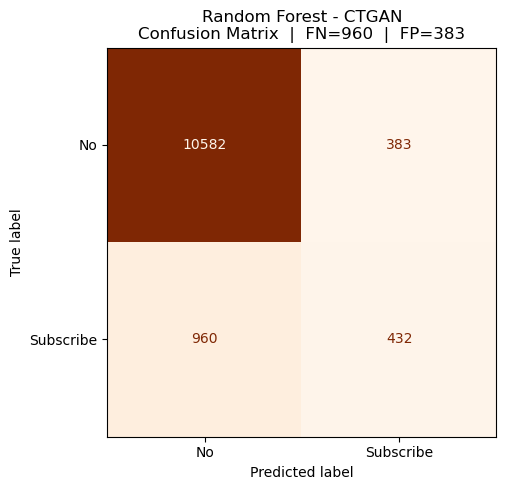


Saved: bank_synthetic_ctgan_final.csv


In [37]:
if synthetic_ctgan_corrected is not None:
    # Build the augmented training set: real training data + synthetic minority
    synth_ctgan_features = synthetic_ctgan_corrected.drop(columns=['y'])
    X_train_ctgan = pd.concat([X_train, synth_ctgan_features], ignore_index=True)
    y_train_ctgan = pd.concat([y_train, pd.Series([1]*len(synth_ctgan_features))],
                              ignore_index=True)

    # Encode with the canonical transformers (no leakage)
    X_train_ctgan_enc = build_matrix(X_train_ctgan)

    print(f"CTGAN-augmented training set: {X_train_ctgan_enc.shape}")
    print(f"Balance: {dict(y_train_ctgan.value_counts())}")

    log_reg_ctgan = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    rf_clf_ctgan  = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    log_reg_ctgan.fit(X_train_ctgan_enc, y_train_ctgan)
    rf_clf_ctgan.fit(X_train_ctgan_enc, y_train_ctgan)

    results_lr_ctgan = evaluate_model(log_reg_ctgan, X_test_enc, y_test,
                                      "Logistic Regression - CTGAN", "Oranges")
    results_rf_ctgan = evaluate_model(rf_clf_ctgan, X_test_enc, y_test,
                                      "Random Forest - CTGAN", "Oranges")

    # Save synthetic data (bank_ prefix)
    synthetic_ctgan_corrected.to_csv("data/bank_synthetic_ctgan_final.csv", index=False)
    print("\nSaved: bank_synthetic_ctgan_final.csv")

### 8.5 CTAB-GAN+

CTAB-GAN+ (Zhao et al., 2023) is trained on the full training set (both classes),
as its auxiliary classifier requires them. Its WGAN-GP optimiser and mixed-type
encoder target training stability and long-tailed distributions. For methodological
consistency with Dataset 1, the mixed-column mechanism is not employed; declaring
spike-at-zero variables such as `previous` as mixed columns is noted as a potential
refinement for future work.

In [29]:
# CTAB-GAN+ (Zhao et al., 2023): WGAN-GP + auxiliary classifier + mixed-type encoder.
# Trained on the FULL training set (both classes needed for the auxiliary classifier),
# unlike CTGAN (minority-only). Not a pip package: import from the cloned repository.
try:
    import sys
    sys.path.append("CTAB-GAN-Plus")   # <-- same path as Dataset 1
    from model.ctabgan import CTABGAN
    CTABGAN_AVAILABLE = True
    print("CTAB-GAN+ imported successfully.")
except ImportError as e:
    print(f"ERROR: Could not import CTAB-GAN+: {e}")
    print("Skipping CTAB-GAN+ section...")
    CTABGAN_AVAILABLE = False

CTAB-GAN+ imported successfully.


In [30]:
if CTABGAN_AVAILABLE:
    import time
    # Full raw training data (both classes — required for auxiliary classifier)
    train_data_full_ctab = X_train.copy()
    train_data_full_ctab['y'] = y_train.values

    csv_path = "data/bank_train_data_full_temp.csv"
    train_data_full_ctab.to_csv(csv_path, index=False)
    print(f"Training data saved to: {csv_path}")

    # Column definitions (adapted to Bank Marketing; NO mixed_columns)
    categorical_columns_ctab = CATEGORICAL_COLS + ['y']
    integer_columns_ctab = INTEGER_COLS   # age, campaign, previous
    # Socio-economic floats are treated as general continuous (correct)

    np.random.seed(RANDOM_STATE)
    try:
        import torch; torch.manual_seed(RANDOM_STATE)
        print("PyTorch seed set.")
    except ImportError:
        print("PyTorch not found - skipping torch seed.")
    print("Data preparation for CTAB-GAN+ completed.")

Training data saved to: data/bank_train_data_full_temp.csv
PyTorch seed set.
Data preparation for CTAB-GAN+ completed.


In [ ]:
if CTABGAN_AVAILABLE:
    print("Initialising CTAB-GAN+ model...")
    ctabgan_model = CTABGAN(
        raw_csv_path=csv_path,
        test_ratio=0.20,   # CTAB-GAN+ holds out a stratified 20% internally (seed 42,
                           # fixed by the library) and trains on the remaining 80%
        categorical_columns=categorical_columns_ctab,
        integer_columns=integer_columns_ctab,
        problem_type={"Classification": "y"},
    )

    print("Training CTAB-GAN+ on full dataset (WGAN-GP)...")
    start_time = time.time()
    ctabgan_model.fit()
    print(f"CTAB-GAN+ training completed in {(time.time()-start_time)/60:.2f} minutes.")

    import pickle
    with open("models/bank_ctabgan_model_trained.pkl", "wb") as f:
        pickle.dump(ctabgan_model, f)
    print("Model saved to models/bank_ctabgan_model_trained.pkl")

Initialising CTAB-GAN+ model...
Training CTAB-GAN+ on full dataset (WGAN-GP)...


 40%|████      | 60/150 [1:36:43<2:25:38, 97.09s/it]

> **Note on the saved output above.** The progress bar stops at 60/150 epochs
> because the rest of the printed output of this ~4-hour run was not captured in
> the saved notebook. Training did complete: `bank_ctabgan_model_trained.pkl` is
> only written after `fit()` returns, and the generation cells below use the
> fully trained model.

In [35]:
if CTABGAN_AVAILABLE:
    num_majority = (y_train == 0).sum()
    num_minority = (y_train == 1).sum()
    samples_to_generate_ctab = num_majority - num_minority
    print(f"Need {samples_to_generate_ctab} synthetic minority samples for 50/50.")
    print("Minority share per batch is not fixed; batches are pooled until the target is reached.\n")

    collected_minority = []
    max_iterations = 20
    iteration = 0
    while True:
        iteration += 1
        if iteration > max_iterations:
            raise RuntimeError(f"Reached max_iterations without target. "
                               f"Collected: {sum(len(b) for b in collected_minority)}.")
        print(f"  [Iteration {iteration}] Generating batch...")
        batch = ctabgan_model.generate_samples()

        # CTAB-GAN+ may return y and was_contacted as float/string; normalise both
        batch["y"] = pd.to_numeric(batch["y"], errors="coerce").round().astype("Int64")
        batch["was_contacted"] = pd.to_numeric(batch["was_contacted"],
                                               errors="coerce").round().astype("Int64")
        if iteration == 1:
            print(f"    y unique: {sorted(batch['y'].dropna().unique())}, dtype {batch['y'].dtype}")

        batch_minority = batch[batch["y"] == 1]
        collected_minority.append(batch_minority)
        total = sum(len(b) for b in collected_minority)
        print(f"    Batch {len(batch)} | minority {len(batch_minority)} "
              f"({len(batch_minority)/len(batch):.1%}) | cumulative {total}")
        if total >= samples_to_generate_ctab:
            print(f"\n  Target reached after {iteration} iteration(s).")
            break

    synthetic_pool_ctab = pd.concat(collected_minority, ignore_index=True)
    synthetic_ctab = synthetic_pool_ctab.sample(n=samples_to_generate_ctab,
                                                random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"\nFinal synthetic CTAB-GAN+ set: {synthetic_ctab.shape}")

Need 22335 synthetic minority samples for 50/50.
Minority share per batch is not fixed; batches are pooled until the target is reached.

  [Iteration 1] Generating batch...
    y unique: [0, 1], dtype Int64
    Batch 28831 | minority 6200 (21.5%) | cumulative 6200
  [Iteration 2] Generating batch...
    Batch 28831 | minority 6095 (21.1%) | cumulative 12295
  [Iteration 3] Generating batch...
    Batch 28831 | minority 6120 (21.2%) | cumulative 18415
  [Iteration 4] Generating batch...
    Batch 28831 | minority 6062 (21.0%) | cumulative 24477

  Target reached after 4 iteration(s).

Final synthetic CTAB-GAN+ set: (22335, 20)


=== CTAB-GAN+ domain violations BEFORE correction ===
  TOTAL: 0
AFTER correction: 0 violations.
Logistic Regression - CTAB-GAN+ - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.94      0.85      0.89     10965
   Subscribe       0.34      0.59      0.43      1392

    accuracy                           0.82     12357
   macro avg       0.64      0.72      0.66     12357
weighted avg       0.87      0.82      0.84     12357

  ROC-AUC:            0.7733
  Avg Precision (PR): 0.4012
  Minority Recall:    0.5884
  Minority Precision: 0.3354
  Minority F1:        0.4272


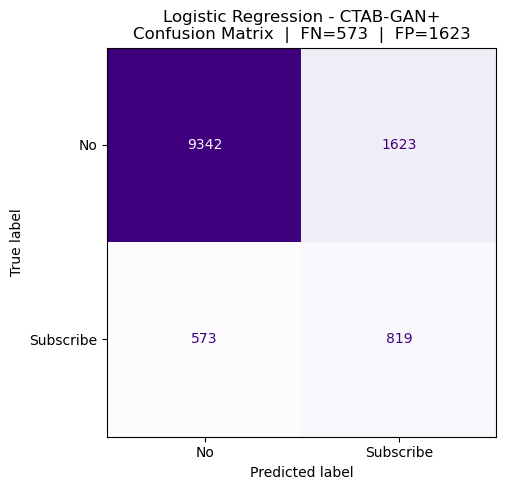

Random Forest - CTAB-GAN+ - CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.92      0.97      0.94     10965
   Subscribe       0.53      0.31      0.39      1392

    accuracy                           0.89     12357
   macro avg       0.72      0.64      0.67     12357
weighted avg       0.87      0.89      0.88     12357

  ROC-AUC:            0.7684
  Avg Precision (PR): 0.4127
  Minority Recall:    0.3103
  Minority Precision: 0.5301
  Minority F1:        0.3915


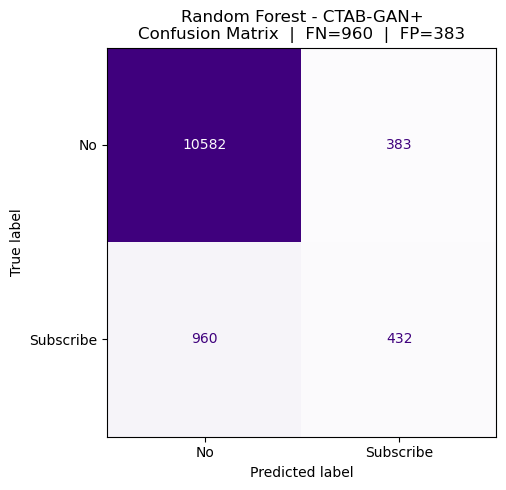


Saved: bank_synthetic_ctab_final.csv


In [36]:
if CTABGAN_AVAILABLE:
    # AUDIT before correction (key evidence — expected near-zero for CTAB-GAN+)
    print("=== CTAB-GAN+ domain violations BEFORE correction ===")
    viol_ctab = audit_domain_violations(synthetic_ctab, "CTAB-GAN+")
    total_ctab = sum(r['violations'] for r in viol_ctab.values())
    for col, r in viol_ctab.items():
        if r['violations'] > 0:
            print(f"  {col:16}: {r['violations']:5} ({r['pct']}%)")
    print(f"  TOTAL: {total_ctab}")

    synthetic_ctab_corrected = correct_domain_violations(synthetic_ctab)
    assert sum(r['violations'] for r in
               audit_domain_violations(synthetic_ctab_corrected).values()) == 0
    print("AFTER correction: 0 violations.")

    # TSTR
    synth_ctab_features = synthetic_ctab_corrected.drop(columns=['y'])
    X_train_ctab = pd.concat([X_train, synth_ctab_features], ignore_index=True)
    y_train_ctab = pd.concat([y_train, pd.Series([1]*len(synth_ctab_features))],
                             ignore_index=True)
    X_train_ctab_enc = build_matrix(X_train_ctab)

    log_reg_ctab = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000).fit(X_train_ctab_enc, y_train_ctab)
    rf_clf_ctab  = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100).fit(X_train_ctab_enc, y_train_ctab)

    results_lr_ctab = evaluate_model(log_reg_ctab, X_test_enc, y_test, "Logistic Regression - CTAB-GAN+", "Purples")
    results_rf_ctab = evaluate_model(rf_clf_ctab, X_test_enc, y_test, "Random Forest - CTAB-GAN+", "Purples")

    synthetic_ctab_corrected.to_csv("data/bank_synthetic_ctab_final.csv", index=False)
    print("\nSaved: bank_synthetic_ctab_final.csv")

## 9. Multidimensional Evaluation (He et al. 2025 — 7 Properties)

This is the central methodological contribution: evaluating synthetic data across
the seven imperceptibility properties of He et al. (2025), adapted to tabular
synthetic data. Statistical utility metrics (AUC, recall) cannot detect domain
violations or structural implausibility; this multidimensional audit can. Each
generator's synthetic minority is compared against the real minority.

In [38]:
# 9.1 — Full fidelity reports for each generator vs the real minority
# (requires synthetic_ctgan_corrected and synthetic_ctab_corrected from Phase 3/4)
report_ctgan, summary_ctgan = compute_fidelity_report(
    train_minority_raw, synthetic_ctgan_corrected.drop(columns=['y']), "CTGAN")
report_ctab, summary_ctab = compute_fidelity_report(
    train_minority_raw, synthetic_ctab_corrected.drop(columns=['y']), "CTAB-GAN+")

fidelity_comparison = pd.DataFrame([summary_ctgan, summary_ctab]).set_index('label')
print("\n=== Fidelity summary (CTGAN vs CTAB-GAN+) ===")
print(fidelity_comparison.round(4).T)


=== Fidelity Report - CTGAN ===
  mean_TVD_cat            : 0.08731818181818184
  mean_KS_cont            : 0.13965
  mean_Wass_cont          : 1.82375
  frobenius_delta         : 1.1156
  mean_proximity          : 1.0388
  ood_rate                : 0.0836
  high_sensitivity_rate   : 0.0

=== Fidelity Report - CTAB-GAN+ ===
  mean_TVD_cat            : 0.0899
  mean_KS_cont            : 0.2225375
  mean_Wass_cont          : 5.856250000000001
  frobenius_delta         : 1.8374
  mean_proximity          : 1.2803
  ood_rate                : 0.0298
  high_sensitivity_rate   : 0.0

=== Fidelity summary (CTGAN vs CTAB-GAN+) ===
label                   CTGAN  CTAB-GAN+
mean_TVD_cat           0.0873     0.0899
mean_KS_cont           0.1396     0.2225
mean_Wass_cont         1.8238     5.8563
frobenius_delta        1.1156     1.8374
mean_proximity         1.0388     1.2803
ood_rate               0.0836     0.0298
high_sensitivity_rate  0.0000     0.0000


### 9.2 The Seven Properties of He et al. (2025)

Quantitative: (1) Proximity, (2) Sparsity, (3) Deviation, (4) Sensitivity.
Qualitative: (5) Immutability, (6) Feasibility, (7) Feature Interdependency.

In [40]:
print("="*70)
print("HE ET AL. (2025) 7-PROPERTY FRAMEWORK — Bank Marketing")
print("="*70)

synth_sets = {"CTGAN": synthetic_ctgan_corrected.drop(columns=['y']),
              "CTAB-GAN+": synthetic_ctab_corrected.drop(columns=['y'])}

# ---- PROPERTY 1: PROXIMITY (NN distance to real, standardised) ----
print("\n[P1] PROXIMITY — mean nearest-neighbour distance to real minority")
scaler_prox = StandardScaler()
real_scaled = scaler_prox.fit_transform(train_minority_raw[CONTINUOUS_COLS].astype(float))
nbrs = NearestNeighbors(n_neighbors=1).fit(real_scaled)
proximity = {}
for name, synth in synth_sets.items():
    d, _ = nbrs.kneighbors(scaler_prox.transform(synth[CONTINUOUS_COLS].astype(float)))
    proximity[name] = d.mean()
    print(f"  {name:10}: {d.mean():.4f} ± {d.std():.4f}   (lower = closer to real)")

# ---- PROPERTY 2: SPARSITY (OOD rate vs P95 real-real) ----
print("\n[P2] SPARSITY — out-of-distribution rate (> P95 of real-real NN distance)")
nbrs_r2r = NearestNeighbors(n_neighbors=2).fit(real_scaled)
d_r2r, _ = nbrs_r2r.kneighbors(real_scaled)
thr95 = np.percentile(d_r2r[:, 1], 95)
sparsity = {}
for name, synth in synth_sets.items():
    d, _ = nbrs.kneighbors(scaler_prox.transform(synth[CONTINUOUS_COLS].astype(float)))
    sparsity[name] = (d[:, 0] > thr95).mean()
    print(f"  {name:10}: {sparsity[name]:.2%}   (lower = fewer OOD records)")

# ---- PROPERTIES 3 & 4: DEVIATION and SENSITIVITY (z-scores) ----
print("\n[P3/P4] DEVIATION (mean |z|) and SENSITIVITY (>3 features at |z|>2)")
mean_real = train_minority_raw[CONTINUOUS_COLS].astype(float).mean()
std_real  = train_minority_raw[CONTINUOUS_COLS].astype(float).std()
deviation, sensitivity = {}, {}
for name, synth in synth_sets.items():
    z = ((synth[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()
    deviation[name] = z.values.mean()
    sensitivity[name] = ((z > 2).sum(axis=1) > 3).mean()
    print(f"  {name:10}: deviation={deviation[name]:.4f}, sensitivity={sensitivity[name]:.2%}")

# ---- PROPERTY 5: IMMUTABILITY (demographic stability, TVD) ----
print("\n[P5] IMMUTABILITY — demographic attribute stability (TVD)")
for col in IMMUTABLE_FEATURES:   # marital, education, job
    tvd_cg = compute_tvd(train_minority_raw[col], synth_sets["CTGAN"][col])
    tvd_ct = compute_tvd(train_minority_raw[col], synth_sets["CTAB-GAN+"][col])
    print(f"  {col:10}: CTGAN TVD={tvd_cg:.4f} | CTAB-GAN+ TVD={tvd_ct:.4f}")

# ---- PROPERTY 6: FEASIBILITY (domain range compliance, POST-correction) ----
print("\n[P6] FEASIBILITY — domain-range compliance (post-correction = 1.000)")
feasibility_features = ['age','campaign','emp.var.rate','euribor3m','nr.employed','cons.price.idx']
feas = {}
for col in feasibility_features:
    r = DOMAIN_RULES[col]
    feas[f"{col} in [{r['min']}, {r['max']}]"] = {
        name: synth[col].between(r['min'], r['max']).mean()
        for name, synth in synth_sets.items()}
print(pd.DataFrame(feas).T.round(4))
print("  NOTE: pre-correction, CTGAN produced 13,764 violations (socio-economic),")
print("  CTAB-GAN+ produced 0. See Phase 3/4 for the pre-correction figures.")

# ---- PROPERTY 7: FEATURE INTERDEPENDENCY (socio-economic correlation) ----
print("\n[P7] FEATURE INTERDEPENDENCY — socio-economic correlation structure")
socio = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
real_corr = train_minority_raw[socio].astype(float).corr()
interdep = {}
for name, synth in synth_sets.items():
    synth_corr = synth[socio].astype(float).corr()
    interdep[name] = np.linalg.norm(real_corr.values - synth_corr.values, 'fro')
    print(f"  {name:10}: Frobenius Δ = {interdep[name]:.4f}   (lower = structure preserved)")

HE ET AL. (2025) 7-PROPERTY FRAMEWORK — Bank Marketing

[P1] PROXIMITY — mean nearest-neighbour distance to real minority
  CTGAN     : 1.0622 ± 0.6754   (lower = closer to real)
  CTAB-GAN+ : 0.8423 ± 0.6374   (lower = closer to real)

[P2] SPARSITY — out-of-distribution rate (> P95 of real-real NN distance)
  CTGAN     : 67.93%   (lower = fewer OOD records)
  CTAB-GAN+ : 58.12%   (lower = fewer OOD records)

[P3/P4] DEVIATION (mean |z|) and SENSITIVITY (>3 features at |z|>2)
  CTGAN     : deviation=0.8180, sensitivity=0.00%
  CTAB-GAN+ : deviation=0.7441, sensitivity=0.00%

[P5] IMMUTABILITY — demographic attribute stability (TVD)
  marital   : CTGAN TVD=0.1580 | CTAB-GAN+ TVD=0.0479
  education : CTGAN TVD=0.1578 | CTAB-GAN+ TVD=0.0696
  job       : CTGAN TVD=0.1442 | CTAB-GAN+ TVD=0.1547

[P6] FEASIBILITY — domain-range compliance (post-correction = 1.000)
                                    CTGAN  CTAB-GAN+
age in [17, 98]                       1.0        1.0
campaign in [1, 56]  

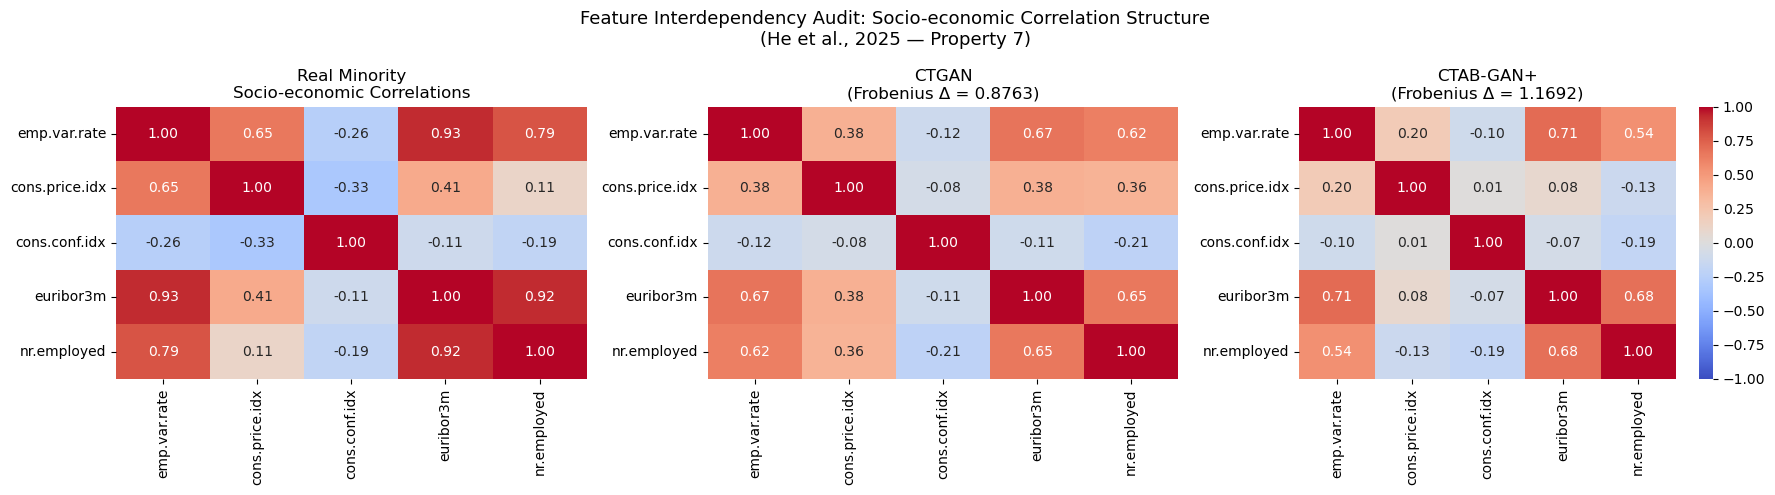

In [41]:
# 9.3 — Feature Interdependency visualisation (He et al. Property 7)
socio = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
real_corr  = train_minority_raw[socio].astype(float).corr()
ctgan_corr = synthetic_ctgan_corrected[socio].astype(float).corr()
ctab_corr  = synthetic_ctab_corrected[socio].astype(float).corr()

frob_ctgan = np.linalg.norm(real_corr.values - ctgan_corr.values, 'fro')
frob_ctab  = np.linalg.norm(real_corr.values - ctab_corr.values, 'fro')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(real_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[0], cbar=False)
axes[0].set_title("Real Minority\nSocio-economic Correlations")
sns.heatmap(ctgan_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[1], cbar=False)
axes[1].set_title(f"CTGAN\n(Frobenius Δ = {frob_ctgan:.4f})")
sns.heatmap(ctab_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            ax=axes[2])
axes[2].set_title(f"CTAB-GAN+\n(Frobenius Δ = {frob_ctab:.4f})")
plt.suptitle("Feature Interdependency Audit: Socio-economic Correlation Structure\n"
             "(He et al., 2025 — Property 7)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/bank_interdependency_audit.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.4 Consolidated Quality Dimensions Table
Summary rows (the 7 properties + marginal means) plus key per-feature rows that
carry narrative weight: class-discriminating categoricals, immutable demographics,
and the multimodal socio-economic continuous variables.

In [44]:
quality_rows = []

def add_row(dim, metric, prop, cg, ct, lower_better=True):
    if cg == ct:
        favoured = "Tie"
    else:
        favoured = "CTGAN" if ((cg < ct) == lower_better) else "CTAB-GAN+"
    quality_rows.append({"Quality Dimension": dim, "Metric": metric,
                         "He Property": prop, "CTGAN": round(cg, 4),
                         "CTAB-GAN+": round(ct, 4), "Favoured": favoured})

ctgan_min = synthetic_ctgan_corrected.drop(columns=['y'])
ctab_min  = synthetic_ctab_corrected.drop(columns=['y'])

# --- Marginal fidelity summaries ---
add_row("Marginal fidelity (categorical)", "Mean TVD", "-",
        summary_ctgan['mean_TVD_cat'], summary_ctab['mean_TVD_cat'])
add_row("Marginal fidelity (continuous)", "Mean KS", "-",
        summary_ctgan['mean_KS_cont'], summary_ctab['mean_KS_cont'])

# --- Key categorical TVD (class-discriminating features) ---
for col in ['month', 'contact', 'poutcome']:
    add_row(f"  TVD: {col}", "TVD", "-",
            compute_tvd(train_minority_raw[col], ctgan_min[col]),
            compute_tvd(train_minority_raw[col], ctab_min[col]))

# --- Immutable demographic TVD (Property 5) ---
for col in ['marital', 'education']:
    add_row(f"  TVD: {col} (immutable)", "TVD", "P5",
            compute_tvd(train_minority_raw[col], ctgan_min[col]),
            compute_tvd(train_minority_raw[col], ctab_min[col]))

# --- Key continuous KS (multimodal socio-economic) ---
for col in ['euribor3m', 'nr.employed']:
    ks_cg, _ = compute_ks(train_minority_raw[col], ctgan_min[col].astype(float))
    ks_ct, _ = compute_ks(train_minority_raw[col], ctab_min[col].astype(float))
    add_row(f"  KS: {col} (multimodal)", "KS", "-", ks_cg, ks_ct)

# --- The 7 properties (quantitative) ---
add_row("Proximity", "NN distance", "P1", proximity["CTGAN"], proximity["CTAB-GAN+"])
add_row("Sparsity", "OOD rate", "P2", sparsity["CTGAN"], sparsity["CTAB-GAN+"])
add_row("Deviation", "Mean |z-score|", "P3", deviation["CTGAN"], deviation["CTAB-GAN+"])
add_row("Sensitivity", "Multi-feature outliers", "P4",
        sensitivity["CTGAN"], sensitivity["CTAB-GAN+"])
add_row("Feature Interdependency", "Frobenius Δ", "P7",
        interdep["CTGAN"], interdep["CTAB-GAN+"])

quality_df = pd.DataFrame(quality_rows)
print(quality_df.to_string(index=False))

# Tally excluding indented per-feature rows (count only top-level dimensions)
top_level = quality_df[~quality_df["Quality Dimension"].str.startswith("  ")]
print(f"\nFavoured tally (main dimensions): {top_level['Favoured'].value_counts().to_dict()}")

# P6 Feasibility reported separately (count metric, not per-record)
print("\nP6 Feasibility (pre-correction domain violations): "
      "CTGAN 13,764 | CTAB-GAN+ 0  ->  Favoured: CTAB-GAN+")

              Quality Dimension                 Metric He Property  CTGAN  CTAB-GAN+  Favoured
Marginal fidelity (categorical)               Mean TVD           - 0.0873     0.0899     CTGAN
 Marginal fidelity (continuous)                Mean KS           - 0.1396     0.2225     CTGAN
                     TVD: month                    TVD           - 0.1445     0.2020     CTGAN
                   TVD: contact                    TVD           - 0.0005     0.0500     CTGAN
                  TVD: poutcome                    TVD           - 0.0585     0.2386     CTGAN
       TVD: marital (immutable)                    TVD          P5 0.1580     0.0479 CTAB-GAN+
     TVD: education (immutable)                    TVD          P5 0.1578     0.0696 CTAB-GAN+
     KS: euribor3m (multimodal)                     KS           - 0.1762     0.2458     CTGAN
   KS: nr.employed (multimodal)                     KS           - 0.1482     0.3119     CTGAN
                      Proximity            NN dist

### 9.5 Save Evaluation Artifacts

In [43]:
quality_df.to_csv("data/bank_quality_dimensions.csv", index=False)
fidelity_comparison.to_csv("data/bank_fidelity_comparison.csv")
report_ctgan.to_csv("data/bank_fidelity_report_ctgan.csv", index=False)
report_ctab.to_csv("data/bank_fidelity_report_ctab.csv", index=False)

print("Saved (all prefixed 'bank_'):")
print("  bank_quality_dimensions.csv     — consolidated quality table")
print("  bank_fidelity_comparison.csv    — fidelity summary CTGAN vs CTAB-GAN+")
print("  bank_fidelity_report_ctgan.csv  — per-column CTGAN fidelity")
print("  bank_fidelity_report_ctab.csv   — per-column CTAB-GAN+ fidelity")

Saved (all prefixed 'bank_'):
  bank_quality_dimensions.csv     — consolidated quality table
  bank_fidelity_comparison.csv    — fidelity summary CTGAN vs CTAB-GAN+
  bank_fidelity_report_ctgan.csv  — per-column CTGAN fidelity
  bank_fidelity_report_ctab.csv   — per-column CTAB-GAN+ fidelity


## 10. Privacy Risk Assessment (DCR / NNDR)

The third quality dimension: privacy. Following Lautrup et al. (2025), we measure
Distance to Closest Record (DCR) and Nearest Neighbour Distance Ratio (NNDR) in a
standardised feature space. A generator that memorises real individuals produces
synthetic records dangerously close to them; these metrics quantify that risk.

In [46]:
# 10.1 — Feature space and standardisation for privacy distances.
# Bank Marketing has no ordinal columns, so PRIVACY_COLS = continuous features.
# A separate scaler is fitted on the real minority only (no leakage from synthetic),
# distinct from the canonical training scaler (mirrors Dataset 1).
PRIVACY_COLS = [c for c in CONTINUOUS_COLS if c in train_minority_raw.columns]
print(f"Privacy feature space ({len(PRIVACY_COLS)}): {PRIVACY_COLS}")

scaler_priv = StandardScaler()
real_priv_scaled  = scaler_priv.fit_transform(train_minority_raw[PRIVACY_COLS].astype(float))
ctgan_priv_scaled = scaler_priv.transform(synthetic_ctgan_corrected[PRIVACY_COLS].astype(float))
ctab_priv_scaled  = scaler_priv.transform(synthetic_ctab_corrected[PRIVACY_COLS].astype(float))
print("Scaler fitted on real minority only — no leakage from synthetic.")

Privacy feature space (8): ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Scaler fitted on real minority only — no leakage from synthetic.


In [47]:
# 10.2 — DCR: Distance to Closest Record. For each synthetic record, the distance
# to the nearest real record. DCR=0 => exact copy (max risk). Baseline: real-to-real
# nearest-neighbour distance (leave-one-out via the 2nd neighbour).
nbrs_dcr = NearestNeighbors(n_neighbors=1, metric="euclidean", n_jobs=-1).fit(real_priv_scaled)
dcr_ctgan = nbrs_dcr.kneighbors(ctgan_priv_scaled)[0].flatten()
dcr_ctab  = nbrs_dcr.kneighbors(ctab_priv_scaled)[0].flatten()

nbrs_r2r = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1).fit(real_priv_scaled)
dcr_real = nbrs_r2r.kneighbors(real_priv_scaled)[0][:, 1]   # 2nd neighbour = leave-one-out

# 5th-percentile risk threshold (CTABGAN/Zhao convention)
p5_threshold = np.percentile(dcr_real, 5)
print("=== DCR: Distance to Closest Record ===")
for name, dcr in [("CTGAN", dcr_ctgan), ("CTAB-GAN+", dcr_ctab), ("Real (baseline)", dcr_real)]:
    print(f"  {name:16}: median={np.median(dcr):.4f}, mean={dcr.mean():.4f}")
risk_ctgan = (dcr_ctgan < p5_threshold).mean()
risk_ctab  = (dcr_ctab < p5_threshold).mean()
print(f"\n  P5 threshold (real): {p5_threshold:.4f}")
print(f"  % below threshold (risk): CTGAN {risk_ctgan:.2%}, CTAB-GAN+ {risk_ctab:.2%}")

# Safety: median synthetic DCR should be >= median real baseline
print(f"\n  Safety check (median synth >= median real baseline):")
print(f"    CTGAN:     {np.median(dcr_ctgan):.4f} >= {np.median(dcr_real):.4f} -> "
      f"{'SAFE' if np.median(dcr_ctgan) >= np.median(dcr_real) else 'REVIEW'}")
print(f"    CTAB-GAN+: {np.median(dcr_ctab):.4f} >= {np.median(dcr_real):.4f} -> "
      f"{'SAFE' if np.median(dcr_ctab) >= np.median(dcr_real) else 'REVIEW'}")

=== DCR: Distance to Closest Record ===
  CTGAN           : median=0.9926, mean=1.0622
  CTAB-GAN+       : median=0.7654, mean=0.8423
  Real (baseline) : median=0.0726, mean=0.1518

  P5 threshold (real): 0.0000
  % below threshold (risk): CTGAN 0.00%, CTAB-GAN+ 0.00%

  Safety check (median synth >= median real baseline):
    CTGAN:     0.9926 >= 0.0726 -> SAFE
    CTAB-GAN+: 0.7654 >= 0.0726 -> SAFE


In [48]:
# 10.3 — NNDR: Nearest Neighbour Distance Ratio = dist(NN1)/dist(NN2). Close to 1 =
# safe (equidistant from two reals); close to 0 = risk (very close to one specific
# real record).
nbrs_nndr = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1).fit(real_priv_scaled)
eps = 1e-10
def nndr(scaled):
    d = nbrs_nndr.kneighbors(scaled)[0]
    return d[:, 0] / (d[:, 1] + eps)
nndr_ctgan = nndr(ctgan_priv_scaled)
nndr_ctab  = nndr(ctab_priv_scaled)

# Real-to-real NNDR baseline (2nd/3rd neighbour, leave-one-out)
nbrs_r2r3 = NearestNeighbors(n_neighbors=3, metric="euclidean", n_jobs=-1).fit(real_priv_scaled)
d_real3 = nbrs_r2r3.kneighbors(real_priv_scaled)[0]
nndr_real = d_real3[:, 1] / (d_real3[:, 2] + eps)

print("=== NNDR: Nearest Neighbour Distance Ratio ===")
for name, nd in [("CTGAN", nndr_ctgan), ("CTAB-GAN+", nndr_ctab), ("Real (baseline)", nndr_real)]:
    print(f"  {name:16}: median={np.median(nd):.4f}")
risk_nndr_ctgan = (nndr_ctgan < 0.5).mean()
risk_nndr_ctab  = (nndr_ctab < 0.5).mean()
risk_nndr_real  = (nndr_real < 0.5).mean()
print(f"\n  % with NNDR < 0.5 (risk): CTGAN {risk_nndr_ctgan:.2%}, "
      f"CTAB-GAN+ {risk_nndr_ctab:.2%}, Real {risk_nndr_real:.2%}")

=== NNDR: Nearest Neighbour Distance Ratio ===
  CTGAN           : median=0.9860
  CTAB-GAN+       : median=0.9726
  Real (baseline) : median=0.5001

  % with NNDR < 0.5 (risk): CTGAN 0.78%, CTAB-GAN+ 6.69%, Real 49.05%


In [49]:
# 10.4 — Consolidated privacy profile
privacy_profile = pd.DataFrame({
    "Metric": ["DCR median", "DCR mean", "DCR % < P5 (risk)",
               "NNDR median", "NNDR % < 0.5 (risk)"],
    "CTGAN": [np.median(dcr_ctgan), dcr_ctgan.mean(), risk_ctgan,
              np.median(nndr_ctgan), risk_nndr_ctgan],
    "CTAB-GAN+": [np.median(dcr_ctab), dcr_ctab.mean(), risk_ctab,
                  np.median(nndr_ctab), risk_nndr_ctab],
    "Real baseline": [np.median(dcr_real), dcr_real.mean(), 0.05,
                      np.median(nndr_real), risk_nndr_real],
}).round(4)
print(privacy_profile.to_string(index=False))

privacy_profile.to_csv("data/bank_privacy_profile.csv", index=False)
print("\nSaved: bank_privacy_profile.csv")

             Metric  CTGAN  CTAB-GAN+  Real baseline
         DCR median 0.9926     0.7654         0.0726
           DCR mean 1.0622     0.8423         0.1518
  DCR % < P5 (risk) 0.0000     0.0000         0.0500
        NNDR median 0.9860     0.9726         0.5001
NNDR % < 0.5 (risk) 0.0078     0.0669         0.4905

Saved: bank_privacy_profile.csv
